In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
BANK_THEME = dict(
    credit  = '#4CAF93',   
    debit   = '#E07B65',   
    accent  = '#534AB7',  
    warn    = '#F5C842',   
    info    = '#5B8DB8',   
    bg      = '#FAFAFA',
    text    = '#2C2C2C',
    grid    = '#E8E8E8',
)

print('✅  All libraries loaded successfully!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

✅  All libraries loaded successfully!
   pandas  2.2.2
   numpy   1.26.4
   seaborn 0.13.2


In [2]:
np.random.seed(42)
categories = {
    'SALARY':       ('credit', 45000, 55000),
    'FREELANCE':    ('credit',  5000, 20000),
    'INTEREST':     ('credit',   200,   800),
    'REFUND':       ('credit',   300,  3000),
    'TRANSFER_IN':  ('credit',  1000, 25000),
    'RENT':         ('debit',  12000, 15000),
    'GROCERY':      ('debit',    800,  3500),
    'EMI_LOAN':     ('debit',   8500,  9000),
    'ELECTRICITY':  ('debit',    700,  2200),
    'MOBILE_BILL':  ('debit',    299,   799),
    'OTT_SUBS':     ('debit',    149,   649),
    'MEDICAL':      ('debit',    500,  8000),
    'RESTAURANT':   ('debit',    200,  2500),
    'SHOPPING':     ('debit',    500,  8000),
    'FUEL':         ('debit',    500,  3000),
    'ATM_WITHDRAW': ('debit',   2000, 10000),
    'TRANSFER_OUT': ('debit',   1000, 25000),
    'INSURANCE':    ('debit',   1500,  5000),
}

descriptions = {
    'SALARY':       ['SALARY CREDIT HDFC BANK','NEFT-EMPLOYER SALARY','SALARY TRF'],
    'FREELANCE':    ['FREELANCE PAYMENT RAZORPAY','CLIENT PAYMENT NEFT','UPWORK TRANSFER'],
    'INTEREST':     ['INTEREST CREDIT SB AC','SAVINGS INTEREST CREDIT'],
    'REFUND':       ['AMAZON REFUND','FLIPKART REFUND NEFT','IRCTC REFUND'],
    'TRANSFER_IN':  ['NEFT TRANSFER RECEIVED','UPI MONEY RECEIVED','IMPS CREDIT'],
    'RENT':         ['RENT TRANSFER NEFT','HOUSE RENT PAYMENT UPI'],
    'GROCERY':      ['BIG BAZAAR','DMART PURCHASE','ZEPTO ORDER','BLINKIT','RELIANCE FRESH'],
    'EMI_LOAN':     ['EMI HDFC HOME LOAN','PERSONAL LOAN EMI','CAR LOAN EMI ICICI'],
    'ELECTRICITY':  ['BESCOM ELECTRICITY BILL','UPPCL BILL PAYMENT'],
    'MOBILE_BILL':  ['JIO RECHARGE','AIRTEL BILL PAYMENT','VI MONTHLY PLAN'],
    'OTT_SUBS':     ['NETFLIX SUBSCRIPTION','AMAZON PRIME','HOTSTAR SUBSCRIPTION'],
    'MEDICAL':      ['APOLLO PHARMACY','MEDPLUS CHEMIST','PRACTO CONSULTATION'],
    'RESTAURANT':   ['ZOMATO ORDER','SWIGGY DELIVERY','RESTAURANT PAYMENT UPI'],
    'SHOPPING':     ['AMAZON PURCHASE','FLIPKART ORDER','MYNTRA SHOPPING'],
    'FUEL':         ['HP PETROL PUMP','INDIAN OIL FUEL','BPCL FUEL PAYMENT'],
    'ATM_WITHDRAW': ['ATM WITHDRAWAL SBI','ATM CASH HDFC','ATM WITHDRAWAL AXIS'],
    'TRANSFER_OUT': ['NEFT TRANSFER SENT','UPI PAYMENT SENT','IMPS DEBIT'],
    'INSURANCE':    ['LIC PREMIUM','TERM INSURANCE HDFC','HEALTH INSURANCE BAJAJ'],
}

freq_map = {
    'SALARY':1,'RENT':1,'EMI_LOAN':1,'ELECTRICITY':1,'MOBILE_BILL':1,
    'OTT_SUBS':1,'INSURANCE':1,'FREELANCE':0.3,'INTEREST':0.5,'REFUND':0.2,
    'GROCERY':8,'RESTAURANT':6,'SHOPPING':4,'FUEL':4,
    'ATM_WITHDRAW':3,'MEDICAL':0.3,'TRANSFER_IN':2,'TRANSFER_OUT':3,
}

dates   = pd.date_range('2024-01-01', '2024-12-31', freq='D')
records = []
balance = 50000.0
txn_id  = 1000

for month in range(1, 13):
    month_dates = [d for d in dates if d.month == month]
    for cat, freq in freq_map.items():
        txn_type, lo, hi = categories[cat]
        count = max(1,int(freq)) if freq>=1 else (1 if np.random.random()<freq else 0)
        for _ in range(count):
            day    = np.random.choice(month_dates)
            amount = round(np.random.uniform(lo, hi), 2)
            if txn_type == 'credit': balance += amount
            else:                    balance  = max(balance - amount, 500)
            records.append({
                'txn_id':      f'TXN{txn_id:05d}',
                'date':        day.strftime('%Y-%m-%d'),
                'description': np.random.choice(descriptions[cat]),
                'category':    cat,
                'type':        txn_type,
                'amount':      amount,
                'balance':     round(balance, 2),
            })
            txn_id += 1

df_raw = pd.DataFrame(records).sort_values('date').reset_index(drop=True)
# Add 3 suspicious large transactions 
for idx in [50, 150, 250]:
    df_raw.loc[idx, 'amount']      = round(np.random.uniform(55000, 90000), 2)
    df_raw.loc[idx, 'description'] = 'LARGE SUSPICIOUS TRANSFER'
    df_raw.loc[idx, 'category']    = 'SUSPICIOUS'

df_raw.to_csv('bank_statement_data.csv', index=False)

print(f'✅  Dataset generated: {len(df_raw)} transactions')
print(f'   Date range : {df_raw["date"].min()}  →  {df_raw["date"].max()}')
print(f'   Columns    : {list(df_raw.columns)}')
df_raw.head()

✅  Dataset generated: 459 transactions
   Date range : 2024-01-01  →  2024-12-31
   Columns    : ['txn_id', 'date', 'description', 'category', 'type', 'amount', 'balance']


,txn_id,date,description,category,type,amount,balance
0,TXN01034,2024-01-01,IMPS CREDIT,TRANSFER_IN,credit,2525.40,29457.15
1,TXN01028,2024-01-01,HP PETROL PUMP,FUEL,debit,539.09,29088.42
2,TXN01015,2024-01-02,BLINKIT,GROCERY,debit,2647.43,60621.70
3,TXN01037,2024-01-03,NEFT TRANSFER SENT,TRANSFER_OUT,debit,12333.16,500.00
4,TXN01017,2024-01-03,SWIGGY DELIVERY,RESTAURANT,debit,2291.44,56727.27


In [3]:
df = pd.read_csv("bank_statement_data.csv")
print(df)

       txn_id        date             description      category    type  \
0    TXN01034  2024-01-01             IMPS CREDIT   TRANSFER_IN  credit   
1    TXN01028  2024-01-01          HP PETROL PUMP          FUEL   debit   
2    TXN01015  2024-01-02                 BLINKIT       GROCERY   debit   
3    TXN01037  2024-01-03      NEFT TRANSFER SENT  TRANSFER_OUT   debit   
4    TXN01017  2024-01-03         SWIGGY DELIVERY    RESTAURANT   debit   
..        ...         ...                     ...           ...     ...   
454  TXN01454  2024-12-29  NEFT TRANSFER RECEIVED   TRANSFER_IN  credit   
455  TXN01451  2024-12-30      ATM WITHDRAWAL SBI  ATM_WITHDRAW   debit   
456  TXN01428  2024-12-30  HEALTH INSURANCE BAJAJ     INSURANCE   debit   
457  TXN01457  2024-12-31      NEFT TRANSFER SENT  TRANSFER_OUT   debit   
458  TXN01440  2024-12-31  RESTAURANT PAYMENT UPI    RESTAURANT   debit   

       amount   balance  
0     2525.40  29457.15  
1      539.09  29088.42  
2     2647.43  60621.

In [4]:
df.head()

,txn_id,date,description,category,type,amount,balance
0,TXN01034,2024-01-01,IMPS CREDIT,TRANSFER_IN,credit,2525.40,29457.15
1,TXN01028,2024-01-01,HP PETROL PUMP,FUEL,debit,539.09,29088.42
2,TXN01015,2024-01-02,BLINKIT,GROCERY,debit,2647.43,60621.70
3,TXN01037,2024-01-03,NEFT TRANSFER SENT,TRANSFER_OUT,debit,12333.16,500.00
4,TXN01017,2024-01-03,SWIGGY DELIVERY,RESTAURANT,debit,2291.44,56727.27


In [5]:
df.isnull()

,txn_id,date,description,category,type,amount,balance
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
454,False,False,False,False,False,False,False
455,False,False,False,False,False,False,False
456,False,False,False,False,False,False,False
457,False,False,False,False,False,False,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   txn_id       459 non-null    object 
 1   date         459 non-null    object 
 2   description  459 non-null    object 
 3   category     459 non-null    object 
 4   type         459 non-null    object 
 5   amount       459 non-null    float64
 6   balance      459 non-null    float64
dtypes: float64(2), object(5)
memory usage: 25.2+ KB


In [7]:

df['date'] = pd.to_datetime(df['date'])
df['month_num'] = df['date'].dt.month
credits = df[df['type'] == 'credit']
debits  = df[df['type'] == 'debit']
monthly_in = (credits.groupby('month_num')['amount'].sum())
monthly_out = (debits.groupby('month_num')['amount'].sum())
net_flow = monthly_in - monthly_out

In [8]:
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

total_income  = credits['amount'].sum()
total_expense = debits['amount'].sum()
net_savings   = total_income - total_expense
savings_rate  = (net_savings / total_income * 100) if total_income > 0 else 0
avg_balance   = df['balance'].mean()
min_balance   = df['balance'].min()
max_balance   = df['balance'].max()

print('=' * 52)
print('   BANK STATEMENT SUMMARY  (Jan–Dec 2024)')
print('=' * 52)
print(f'  Total Transactions : {len(df):>8}')
print(f'  Total Income       : ₹{total_income:>12,.2f}')
print(f'  Total Expense      : ₹{total_expense:>12,.2f}')
print(f'  Net Savings        : ₹{net_savings:>12,.2f}')
print(f'  Savings Rate       : {savings_rate:>7.1f}%')
print('=' * 52)
print()
print('Top 5 Expense Categories:')
top5 = debits.groupby('category')['amount'].sum().sort_values(ascending=False).head(5)
for cat, amt in top5.items():
    print(f'  {cat:<18}  ₹{amt:>10,.2f}')
print()
print('Income Sources:')
inc_src = credits.groupby('category')['amount'].sum().sort_values(ascending=False)
for cat, amt in inc_src.items():
    pct = amt/total_income*100
    print(f'  {cat:<18}  ₹{amt:>10,.2f}  ({pct:.1f}%)')

   BANK STATEMENT SUMMARY  (Jan–Dec 2024)
  Total Transactions :      459
  Total Income       : ₹  940,035.43
  Total Expense      : ₹1,806,465.88
  Net Savings        : ₹ -866,430.45
  Savings Rate       :   -92.2%

Top 5 Expense Categories:
  TRANSFER_OUT        ₹421,548.93
  SUSPICIOUS          ₹221,599.74
  SHOPPING            ₹216,196.35
  ATM_WITHDRAW        ₹214,436.31
  GROCERY             ₹202,972.42

Income Sources:
  SALARY              ₹603,547.90  (64.2%)
  TRANSFER_IN         ₹307,081.43  (32.7%)
  FREELANCE           ₹ 24,795.96  (2.6%)
  INTEREST            ₹  2,915.30  (0.3%)
  REFUND              ₹  1,694.84  (0.2%)


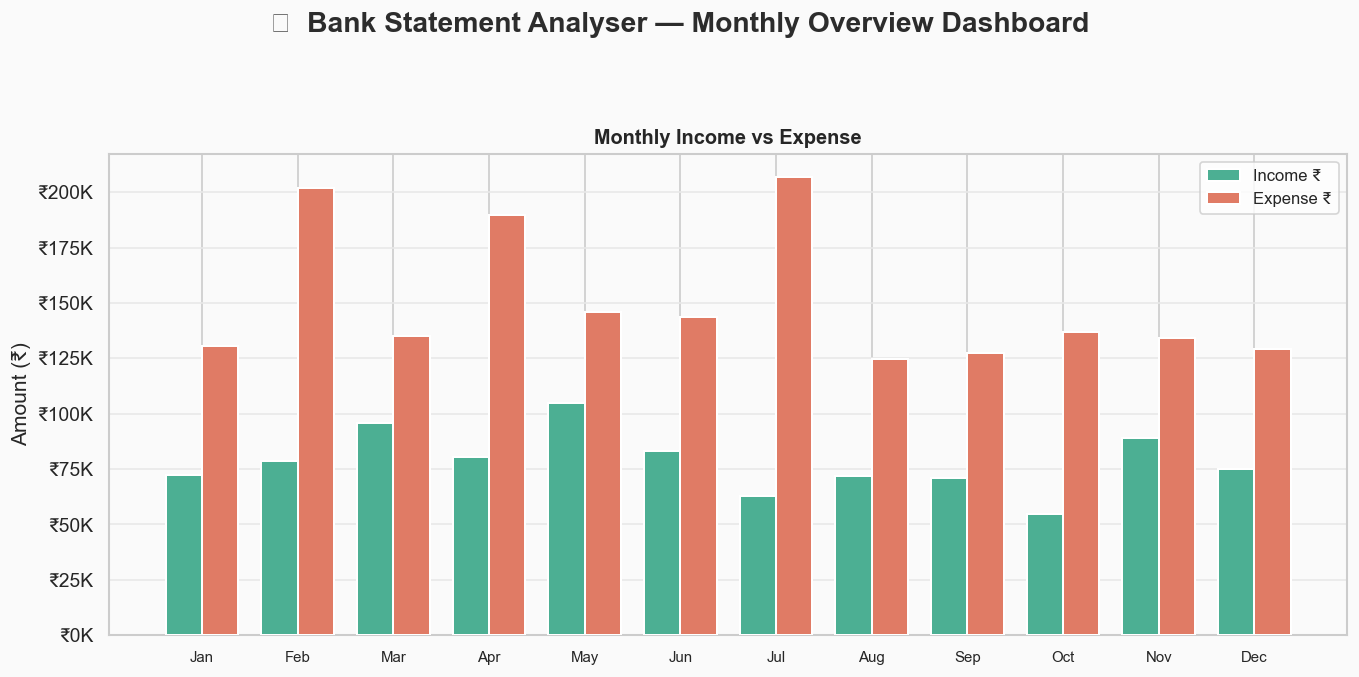

✅  Figure 1 saved → fig1_monly_income_vs_expense.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6),facecolor=BANK_THEME['bg'])
fig.suptitle('📄  Bank Statement Analyser — Monthly Overview Dashboard',
             fontsize=17, fontweight='bold', color=BANK_THEME['text'])
ax.set_facecolor(BANK_THEME['bg'])
x, w = np.arange(12), 0.38
ax.bar(x - w/2, [monthly_in.get(m, 0)  for m in range(1,13)],
       width=w, color=BANK_THEME['credit'], edgecolor='white', lw=1.2, label='Income ₹', zorder=3)
ax.bar(x + w/2, [monthly_out.get(m, 0) for m in range(1,13)],
       width=w, color=BANK_THEME['debit'],  edgecolor='white', lw=1.2, label='Expense ₹', zorder=3)
ax.set_xticks(x); ax.set_xticklabels(MONTH_LABELS, fontsize=9)
ax.set_title('Monthly Income vs Expense', fontsize=12, fontweight='bold')
ax.set_ylabel('Amount (₹)')
ax.yaxis.grid(True, color=BANK_THEME['grid'], zorder=0); ax.set_axisbelow(True)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
plt.tight_layout(pad=2.5)
plt.savefig('fig1_monly_income_vs_expense.png', dpi=150, bbox_inches='tight', facecolor=BANK_THEME['bg'])
plt.show()
print('✅  Figure 1 saved → fig1_monly_income_vs_expense.png')

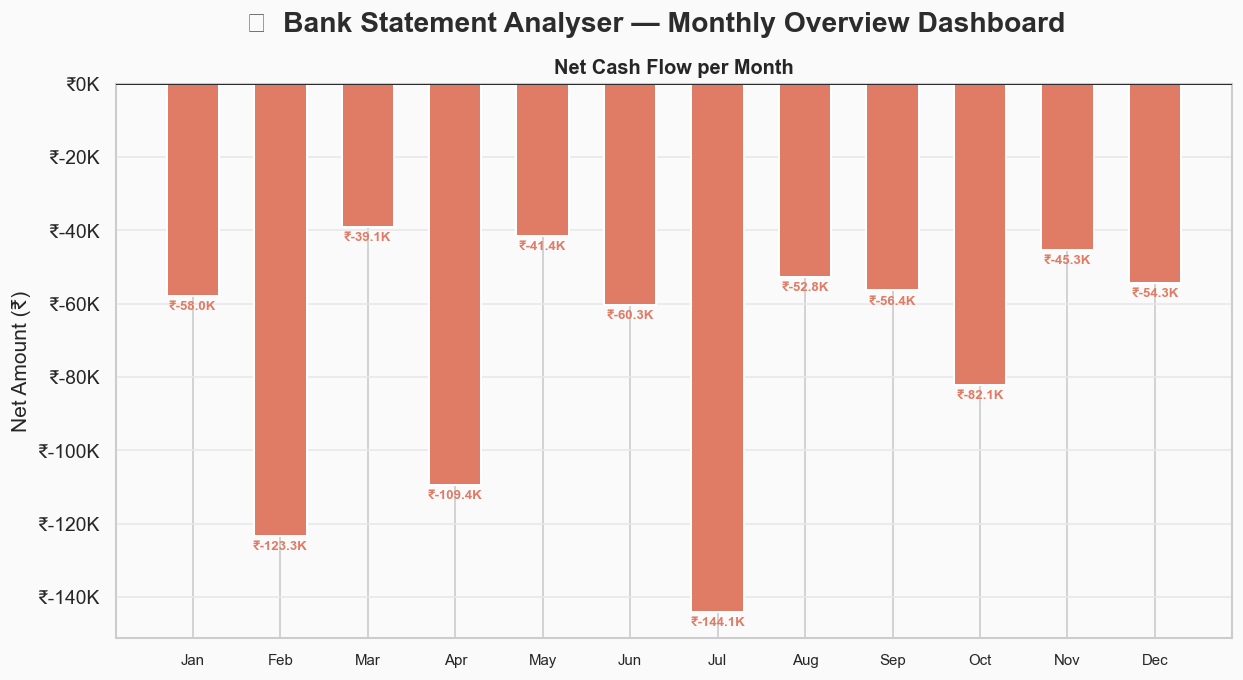

✅  Figure 2 saved → fig2_Net_Cash_Flow_per_Month.png


In [10]:
fig, ax = plt.subplots(figsize=(12, 6),facecolor=BANK_THEME['bg'])
fig.suptitle('📄  Bank Statement Analyser — Monthly Overview Dashboard',
             fontsize=17, fontweight='bold', color=BANK_THEME['text'])
ax.set_facecolor(BANK_THEME['bg'])
nf = [net_flow.get(m, 0) for m in range(1,13)]
bar_colors = [BANK_THEME['credit'] if v >= 0 else BANK_THEME['debit'] for v in nf]
bars = ax.bar(MONTH_LABELS, nf, color=bar_colors,
              edgecolor='white', lw=1.2, zorder=3, width=0.6)
ax.axhline(0, color=BANK_THEME['text'], lw=1.2, zorder=4)
for bar, v in zip(bars, nf):
    offset = 800 if v >= 0 else -3800
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
            f'₹{v/1000:.1f}K', ha='center', fontsize=8, fontweight='bold',
            color=BANK_THEME['credit'] if v >= 0 else BANK_THEME['debit'])
ax.set_title('Net Cash Flow per Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Net Amount (₹)')
ax.yaxis.grid(True, color=BANK_THEME['grid'], zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
ax.tick_params(axis='x', labelsize=9)
plt.savefig('fig2_Net_Cash_Flow_per_Month.png', dpi=150, bbox_inches='tight', facecolor=BANK_THEME['bg'])
plt.show()
print('✅  Figure 2 saved → fig2_Net_Cash_Flow_per_Month.png')

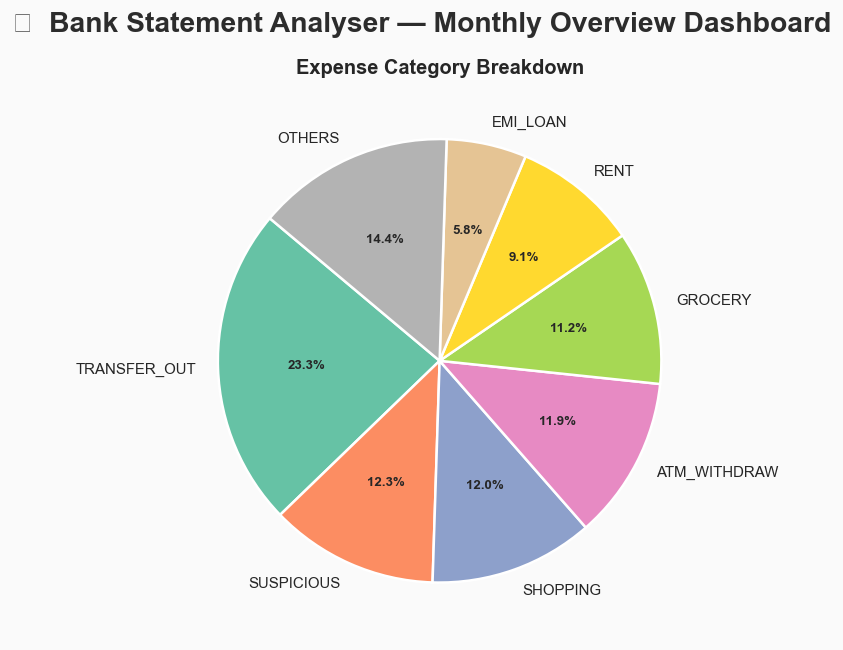

✅  Figure 3 saved → fig3_Expence_Category_BreakDown.png


In [11]:
fig, ax = plt.subplots(figsize=(12, 6),facecolor=BANK_THEME['bg'])
fig.suptitle('📄  Bank Statement Analyser — Monthly Overview Dashboard',
             fontsize=17, fontweight='bold', color=BANK_THEME['text'])
ax.set_facecolor(BANK_THEME['bg'])
cat_totals = debits.groupby('category')['amount'].sum().sort_values(ascending=False)
top_cats   = cat_totals.head(7)
others     = pd.Series({'OTHERS': cat_totals.iloc[7:].sum()}) if len(cat_totals)>7 else pd.Series(dtype=float)
pie_data   = pd.concat([top_cats, others])
wedges, texts, autotexts = ax.pie(
    pie_data.values, labels=pie_data.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('Set2', len(pie_data)),
    wedgeprops={'edgecolor':'white','linewidth':1.5},
    textprops={'fontsize': 9})
for at in autotexts: at.set_fontsize(8); at.set_fontweight('bold')
ax.set_title('Expense Category Breakdown', fontsize=12, fontweight='bold')
plt.savefig('fig3_Expence_Category_BreakDown.png', dpi=150, bbox_inches='tight', facecolor=BANK_THEME['bg'])
plt.show()
print('✅  Figure 3 saved → fig3_Expence_Category_BreakDown.png')

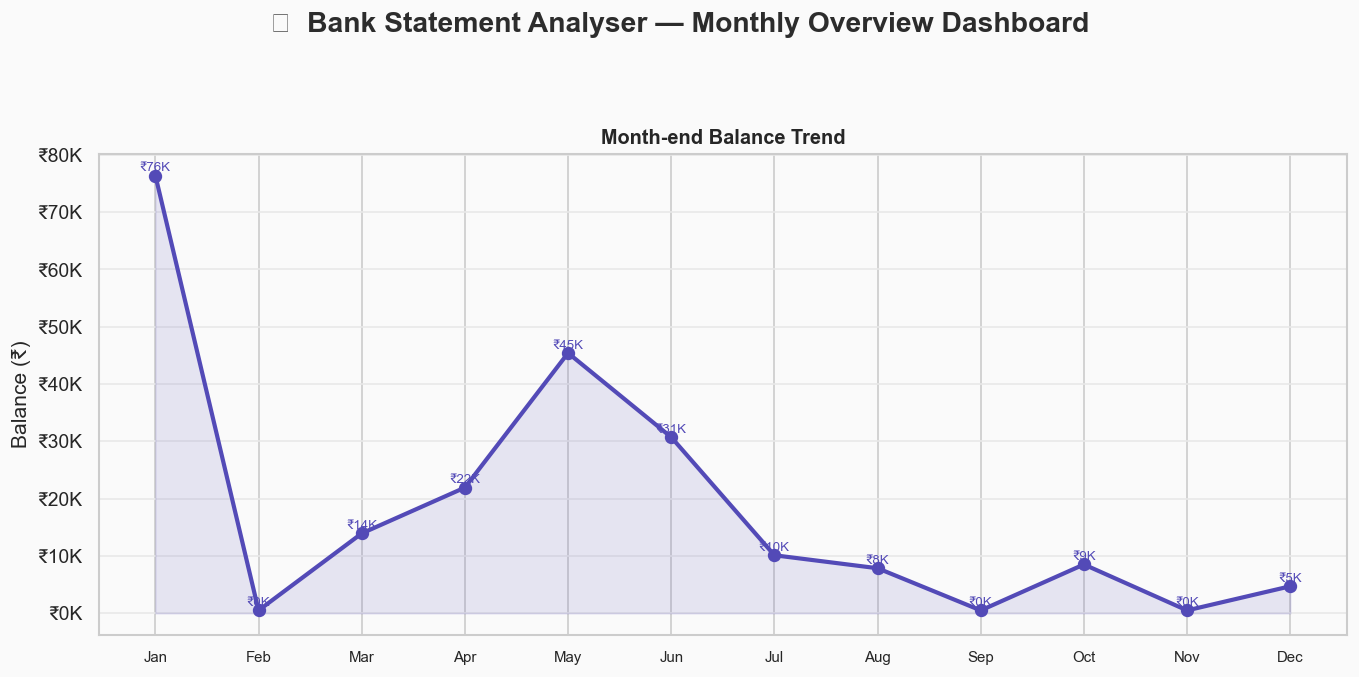

✅  Figure 4 saved → fig4_Month-end Balance Trend.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 6),facecolor=BANK_THEME['bg'])
fig.suptitle('📄  Bank Statement Analyser — Monthly Overview Dashboard',
             fontsize=17, fontweight='bold', color=BANK_THEME['text'])
ax.set_facecolor(BANK_THEME['bg'])
bal_monthly = df.groupby('month_num')['balance'].last()
bal_vals = [bal_monthly.get(m, np.nan) for m in range(1,13)]
ax.plot(MONTH_LABELS, bal_vals, color=BANK_THEME['accent'],
        lw=2.5, marker='o', markersize=7, zorder=3)
ax.fill_between(MONTH_LABELS, bal_vals, alpha=0.12, color=BANK_THEME['accent'])
for i, (lbl, v) in enumerate(zip(MONTH_LABELS, bal_vals)):
    if not np.isnan(v):
        ax.text(i, v + 800, f'₹{v/1000:.0f}K', ha='center', fontsize=8, color=BANK_THEME['accent'])
ax.set_title('Month-end Balance Trend', fontsize=12, fontweight='bold')
ax.set_ylabel('Balance (₹)')
ax.yaxis.grid(True, color=BANK_THEME['grid'], zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout(pad=2.5)
plt.savefig('fig4_Month-end Balance Trend.png', dpi=150, bbox_inches='tight', facecolor=BANK_THEME['bg'])
plt.show()
print('✅  Figure 4 saved → fig4_Month-end Balance Trend.png')

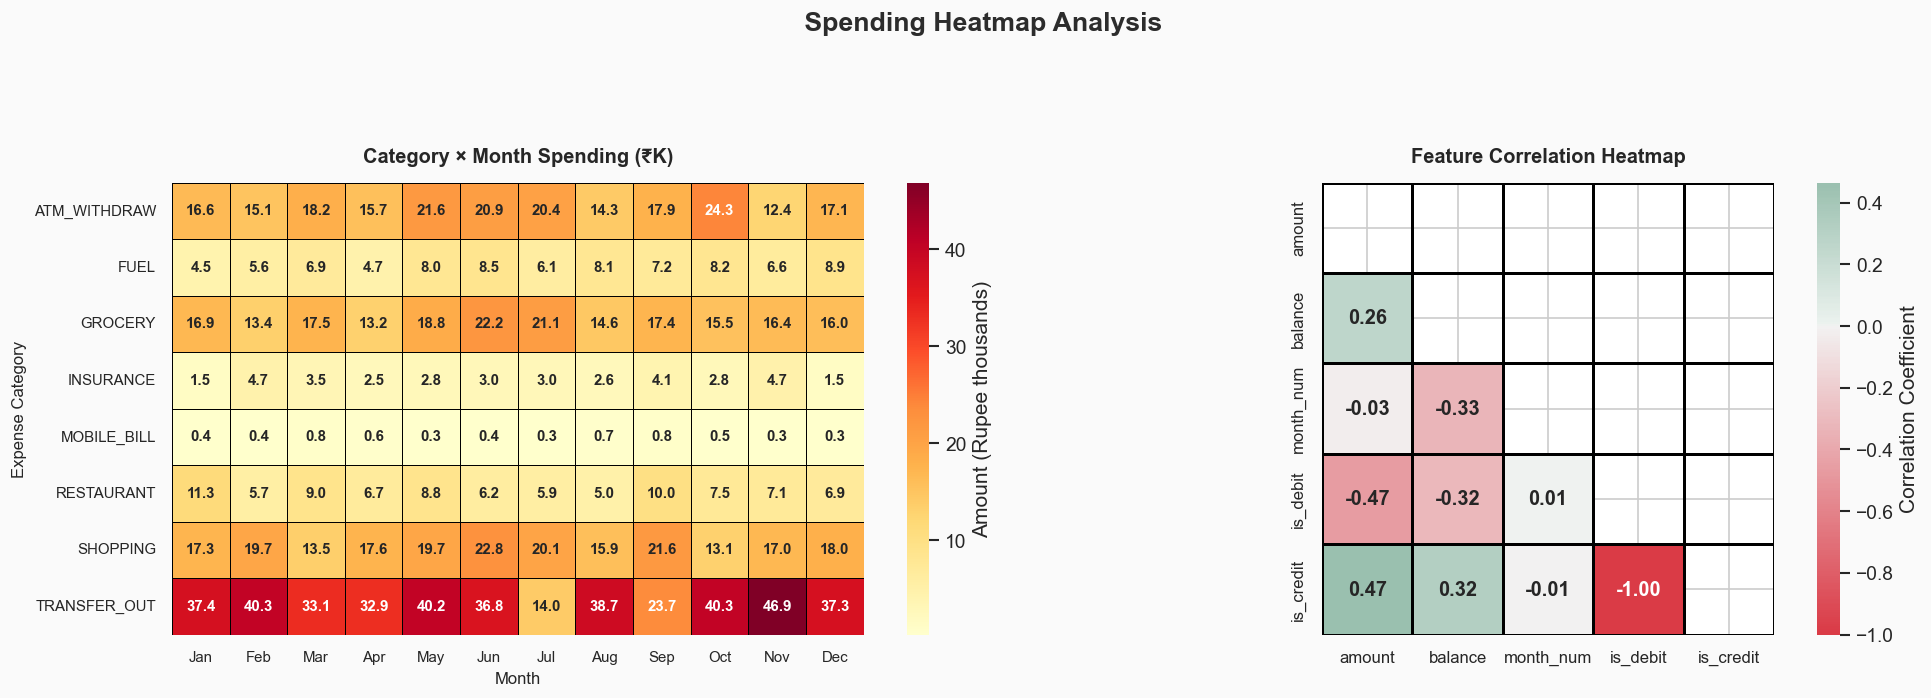

✅  Figure 5 saved → fig5_heatmaps.png


In [13]:
fig2, axes2 = plt.subplots(1, 2, figsize=(17, 6), facecolor=BANK_THEME['bg'])
fig2.suptitle(' Spending Heatmap Analysis',fontsize=16, fontweight='bold', color=BANK_THEME['text'], y=1.01)
# ── Heatmap 1: Category × Month Spending 
ax = axes2[0]
top_debit_cats = debits['category'].value_counts().head(8).index.tolist()
pivot = (debits[debits['category'].isin(top_debit_cats)].groupby(['category', 'month_num'])['amount']
         .sum().unstack(fill_value=0))
pivot.columns = MONTH_LABELS[:pivot.shape[1]]

sns.heatmap(
    pivot / 1000,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5, linecolor='black',
    annot_kws={'size': 9, 'weight': 'bold'},
    cbar_kws={'label': 'Amount (Rupee thousands)'},
    ax=ax
)
ax.set_title('Category × Month Spending (₹K)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Expense Category', fontsize=10)
ax.tick_params(labelsize=9)

# ── Heatmap 2: Feature Correlation 
ax = axes2[1]
num_df = df.copy()
num_df['is_debit']  = (num_df['type'] == 'debit').astype(int)
num_df['is_credit'] = (num_df['type'] == 'credit').astype(int)
corr = num_df[['amount','balance','month_num','is_debit','is_credit']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f',
    cmap=sns.diverging_palette(10, 150, as_cmap=True),
    center=0, linewidths=1.5, linecolor='black',
    annot_kws={'size': 12, 'weight': 'bold'},
    square=True, ax=ax,
    cbar_kws={'label': 'Correlation Coefficient'}
)
ax.set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold', pad=12)
ax.tick_params(labelsize=10)

plt.tight_layout(pad=2.5)
plt.savefig('fig5_heatmaps.png', dpi=150, bbox_inches='tight', facecolor=BANK_THEME['bg'])
plt.show()
print('✅  Figure 5 saved → fig5_heatmaps.png')

IQR Threshold : ₹19,693.69
Normal txns   : 437
Anomalies     : 22

 Top Anomalous Transactions:
      date               description   category   type   amount
2024-07-14 LARGE SUSPICIOUS TRANSFER SUSPICIOUS  debit 84848.76
2024-02-07 LARGE SUSPICIOUS TRANSFER SUSPICIOUS  debit 71355.88
2024-04-28 LARGE SUSPICIOUS TRANSFER SUSPICIOUS  debit 65395.10
2024-03-18                SALARY TRF     SALARY credit 53377.10
2024-11-24   SALARY CREDIT HDFC BANK     SALARY credit 53068.50
2024-01-07                SALARY TRF     SALARY credit 52965.43
2024-02-15   SALARY CREDIT HDFC BANK     SALARY credit 52132.45
2024-08-07                SALARY TRF     SALARY credit 51871.66


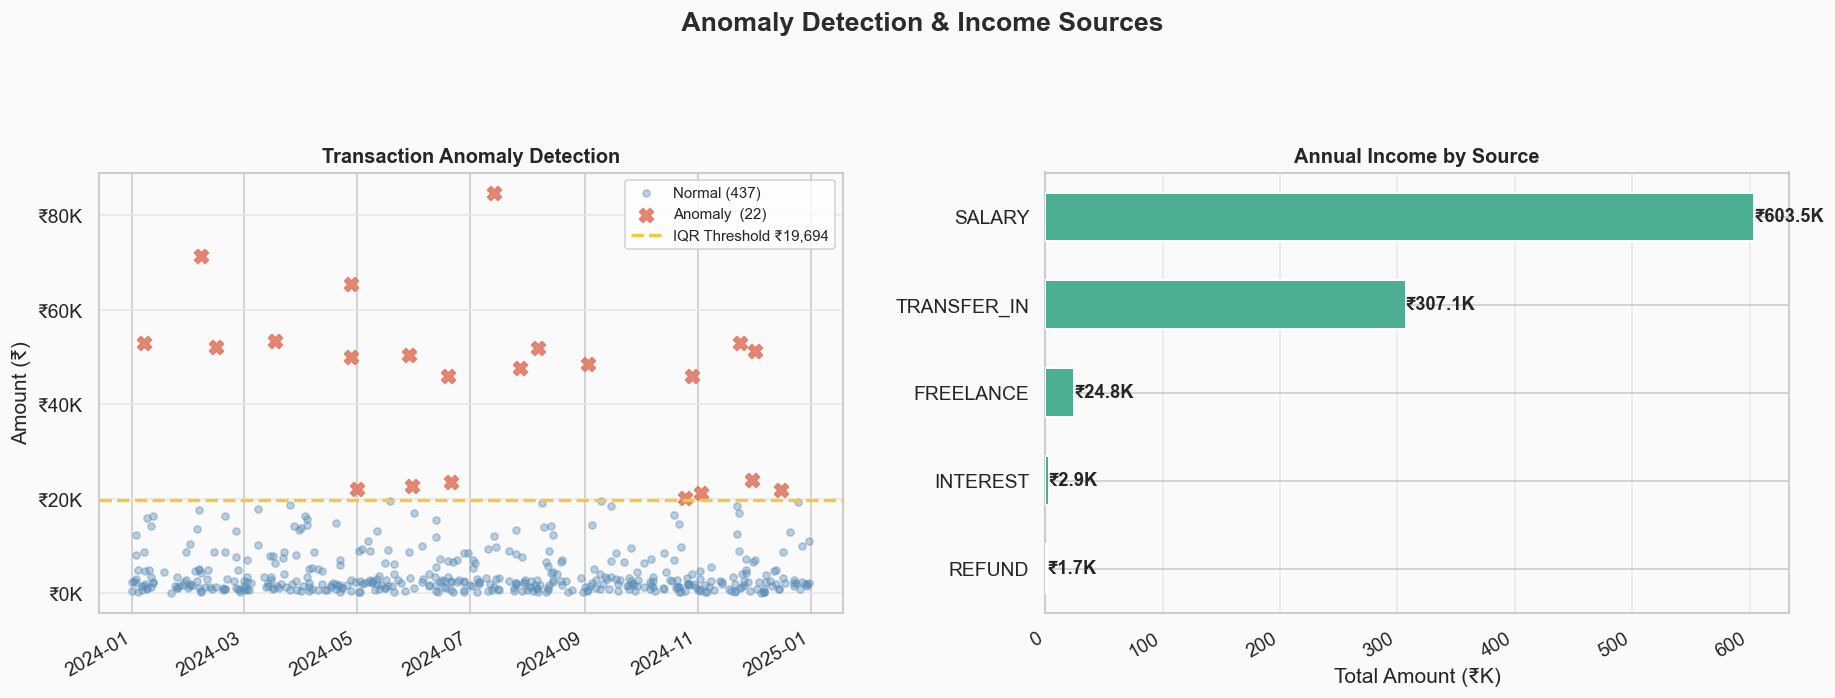

✅  Figure 6 saved → fig6_anomaly.png


In [14]:
# ─── IQR based anomaly detection 
Q1        = df['amount'].quantile(0.25)
Q3        = df['amount'].quantile(0.75)
IQR       = Q3 - Q1
threshold = Q3 + 2.5 * IQR
df['is_anomaly'] = df['amount'] > threshold
normal_txns      = df[~df['is_anomaly']]
anomaly_txns     = df[df['is_anomaly']]

print(f'IQR Threshold : ₹{threshold:,.2f}')
print(f'Normal txns   : {len(normal_txns)}')
print(f'Anomalies     : {len(anomaly_txns)}')
print()
if len(anomaly_txns) > 0:
    print(' Top Anomalous Transactions:')
    print(anomaly_txns[['date','description','category','type','amount']]
          .sort_values('amount', ascending=False)
          .head(8)
          .to_string(index=False))
# ─── Plots 
fig6, axes3 = plt.subplots(1, 2, figsize=(16, 6), facecolor=BANK_THEME['bg'])
fig6.suptitle(' Anomaly Detection & Income Sources',
              fontsize=16, fontweight='bold', color=BANK_THEME['text'], y=1.01)

# Chart 1 — Scatter anomaly
ax = axes3[0]
ax.set_facecolor(BANK_THEME['bg'])
ax.scatter(normal_txns['date'], normal_txns['amount'],
           alpha=0.4, s=18, color=BANK_THEME['info'],
           label=f'Normal ({len(normal_txns)})', zorder=3)
ax.scatter(anomaly_txns['date'], anomaly_txns['amount'],
           alpha=0.9, s=70, color=BANK_THEME['debit'], marker='X',
           label=f'Anomaly  ({len(anomaly_txns)})', zorder=4)
ax.axhline(threshold, color=BANK_THEME['warn'], lw=2, linestyle='--',
           label=f'IQR Threshold ₹{threshold:,.0f}', zorder=5)
ax.set_title('Transaction Anomaly Detection', fontsize=12, fontweight='bold')
ax.set_ylabel('Amount (₹)')
ax.legend(fontsize=9)
ax.yaxis.grid(True, color=BANK_THEME['grid'], zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
fig6.autofmt_xdate()

# Chart 2 — Top income sources
ax = axes3[1]
ax.set_facecolor(BANK_THEME['bg'])
top_income = credits.groupby('category')['amount'].sum()\
                    .sort_values(ascending=True).tail(6)
bars = ax.barh(top_income.index, top_income.values / 1000,
               color=BANK_THEME['credit'], edgecolor='white', lw=1.2, height=0.55, zorder=3)
for bar, v in zip(bars, top_income.values / 1000):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
            f'₹{v:.1f}K', va='center', fontsize=11, fontweight='bold')
ax.set_title('Annual Income by Source', fontsize=12, fontweight='bold')
ax.set_xlabel('Total Amount (₹K)')
ax.xaxis.grid(True, color=BANK_THEME['grid'], zorder=0); ax.set_axisbelow(True)

plt.tight_layout(pad=2.5)
plt.savefig('fig6_anomaly.png', dpi=150, bbox_inches='tight', facecolor=BANK_THEME['bg'])
plt.show()
print('✅  Figure 6 saved → fig6_anomaly.png')

   PERFIOS-STYLE CREDIT SCORE REPORT
   Salary Regularity  (30%) : 100%  score=1.00
   Expense Control    (25%) : ratio=1.92  score=0.20
   No Bounce Charges  (20%) : count=0     score=1.00
   Low Anomalies      (15%) : count=22    score=0.00
   Balance Health     (10%) : avg=₹15,601  score=0.31
----------------------------------------------------
   Raw Composite Score      : 0.581
   CREDIT SCORE             : 649  (FAIR)


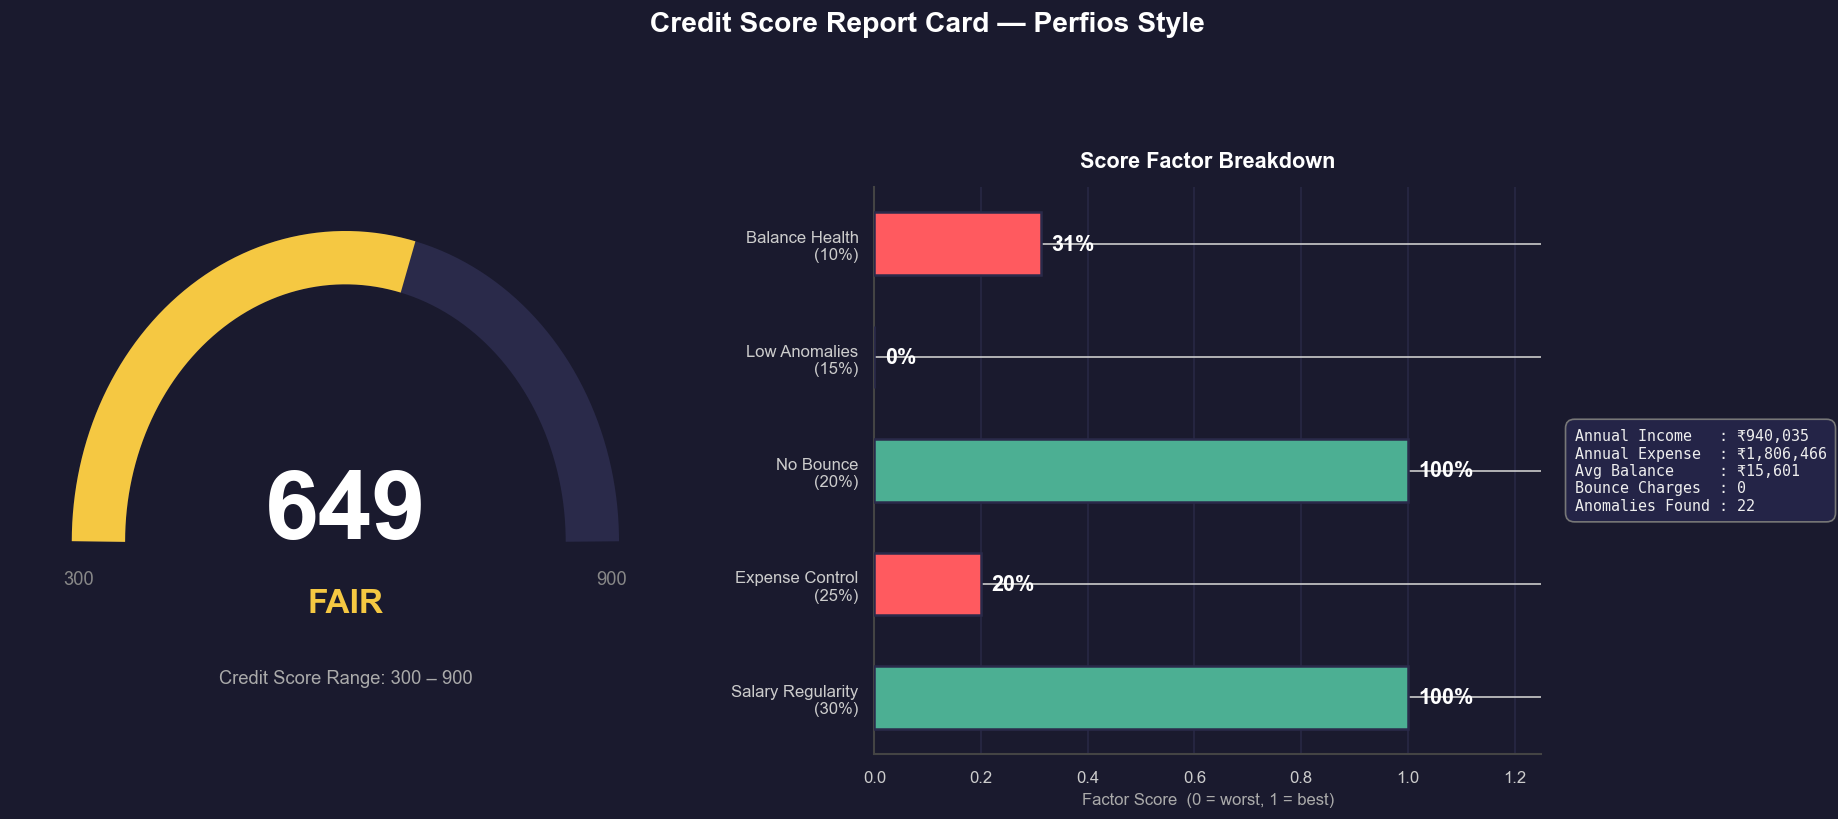

✅  Figure 7 saved → fig4_credit_score.png


In [15]:
# Factor 1: Salary Regularity (30%) — kitne months salary aayi
salary_months     = df[df['category']=='SALARY']['date'].dt.month.nunique()
salary_regularity = min(salary_months / 12, 1.0)
# Factor 2: Expense Control (25%) — expense-to-income ratio
avg_income  = monthly_in.mean()
avg_expense = monthly_out.mean()
expense_ratio = avg_expense / avg_income if avg_income > 0 else 1
if   expense_ratio <= 0.50: expense_score = 1.0   # Excellent
elif expense_ratio <= 0.70: expense_score = 0.8   # Good
elif expense_ratio <= 0.90: expense_score = 0.5   # Fair
else:                       expense_score = 0.2   # Poor
# Factor 3: No Bounce Charges (20%)
bounce_count = len(df[df['category']=='BOUNCE_CHARGE'])
bounce_score = max(0, 1 - bounce_count * 0.2)
# Factor 4: Low Anomalies (15%)
anomaly_count = len(anomaly_txns)
anomaly_score = max(0, 1 - anomaly_count * 0.05)
# Factor 5: Balance Health (10%)
avg_balance   = df['balance'].mean()
balance_score = min(1, avg_balance / 50000)
# ─── Composite score → 300–900 scale 
raw_score    = (salary_regularity * 0.30 +
                expense_score     * 0.25 +
                bounce_score      * 0.20 +
                anomaly_score     * 0.15 +
                balance_score     * 0.10)
credit_score = round(300 + raw_score * 600)
if   credit_score >= 750: tier, tcol = 'EXCELLENT', '#4CAF93'
elif credit_score >= 650: tier, tcol = 'GOOD',      '#85C840'
elif credit_score >= 550: tier, tcol = 'FAIR',      '#F5C842'
else:                     tier, tcol = 'POOR',      '#E07B65'
# ─── Print breakdown 
print('=' * 52)
print('   PERFIOS-STYLE CREDIT SCORE REPORT')
print('=' * 52)
print(f'   Salary Regularity  (30%) : {salary_regularity*100:.0f}%  score={salary_regularity:.2f}')
print(f'   Expense Control    (25%) : ratio={expense_ratio:.2f}  score={expense_score:.2f}')
print(f'   No Bounce Charges  (20%) : count={bounce_count}     score={bounce_score:.2f}')
print(f'   Low Anomalies      (15%) : count={anomaly_count}    score={anomaly_score:.2f}')
print(f'   Balance Health     (10%) : avg=₹{avg_balance:,.0f}  score={balance_score:.2f}')
print('-' * 52)
print(f'   Raw Composite Score      : {raw_score:.3f}')
print(f'   CREDIT SCORE             : {credit_score}  ({tier})')
print('=' * 52)
# ─── Visualise — Gauge + Factor Bars 
factors = {
    'Salary Regularity\n(30%)': salary_regularity,
    'Expense Control\n(25%)':   expense_score,
    'No Bounce\n(20%)':         bounce_score,
    'Low Anomalies\n(15%)':     anomaly_score,
    'Balance Health\n(10%)':    balance_score,
}

fig4, axes4 = plt.subplots(1, 2, figsize=(16, 7), facecolor='#1A1A2E')
fig4.suptitle('  Credit Score Report Card — Perfios Style',
              fontsize=17, fontweight='bold', color='white', y=1.01)
# ── Gauge (donut chart) 
ax = axes4[0]
ax.set_facecolor('#1A1A2E')
theta_bg   = np.linspace(np.pi, 0, 300)
theta_fill = np.linspace(np.pi, np.pi - np.pi * (credit_score-300)/600, 300)
ax.plot(np.cos(theta_bg),   np.sin(theta_bg),   lw=32, color='#2A2A4A', solid_capstyle='butt', zorder=1)
ax.plot(np.cos(theta_fill), np.sin(theta_fill), lw=32, color=tcol,     solid_capstyle='butt', zorder=2, alpha=1)
ax.text(0,  0.10, str(credit_score), ha='center', va='center', fontsize=58, fontweight='bold', color='white')
ax.text(0, -0.22, tier,              ha='center', va='center', fontsize=20, fontweight='bold', color=tcol)
ax.text(0, -0.50, 'Credit Score Range: 300 – 900', ha='center', fontsize=11, color='#aaa')
ax.text(-1.08, -0.15, '300', ha='center', fontsize=11, color='#888')
ax.text( 1.08, -0.15, '900', ha='center', fontsize=11, color='#888')
ax.set_xlim(-1.35, 1.35); ax.set_ylim(-0.75, 1.25)
ax.axis('off')
# ── Factor horizontal bars 
ax = axes4[1]
ax.set_facecolor('#1A1A2E')
names = list(factors.keys())
vals  = list(factors.values())
bar_clrs = ['#4CAF93' if v >= 0.7 else '#F5C842' if v >= 0.4 else '#FF5A5F' for v in vals]
bars = ax.barh(names, vals, color=bar_clrs,
               edgecolor='#2A2A4A', lw=1.5, height=0.55, zorder=3)
for bar, v in zip(bars, vals):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2,
            f'{v*100:.0f}%', va='center', fontsize=13, fontweight='bold', color='white')
ax.set_xlim(0, 1.25)
ax.set_title('Score Factor Breakdown', fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Factor Score  (0 = worst, 1 = best)', color='#aaa', fontsize=10)
ax.tick_params(colors='#ccc', labelsize=10)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
for spine in ['bottom','left']: ax.spines[spine].set_color('#444')
ax.xaxis.grid(True, color='#35355A',alpha = 0.5, zorder=0); ax.set_axisbelow(True)
# Summary stats box inside the chart
summary_txt = (f'Annual Income   : ₹{monthly_in.sum():,.0f}\n'
               f'Annual Expense  : ₹{monthly_out.sum():,.0f}\n'
               f'Avg Balance     : ₹{avg_balance:,.0f}\n'
               f'Bounce Charges  : {bounce_count}\n'
               f'Anomalies Found : {anomaly_count}')
ax.text(1.05, 0.5, summary_txt, transform=ax.transAxes,
        fontsize=9, color='#EEEEEE', va='center', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#242447', edgecolor='#777'))

plt.tight_layout(pad=2.5)
plt.savefig('fig7_credit_score.png', dpi=150, bbox_inches='tight', facecolor='#1A1A2E')
plt.show()
print(f'✅  Figure 7 saved → fig4_credit_score.png')

In [16]:
print('=' * 60)
print('  BANK STATEMENT EDA — FINAL INSIGHTS')
print('=' * 60)
# Insight 1: Savings
total_income  = credits['amount'].sum()
total_expense = debits['amount'].sum()
savings_rate  = (total_income - total_expense) / total_income * 100
print(f'\n1. SAVINGS HEALTH')
print(f'   Total Income  : ₹{total_income:,.0f}')
print(f'   Total Expense : ₹{total_expense:,.0f}')
print(f'   Savings Rate  : {savings_rate:.1f}%  ', end='')
print('✅ Healthy (>20%)' if savings_rate>20 else '  Low (<20%)')
# Insight 2: Biggest expense
biggest = debits.groupby('category')['amount'].sum().idxmax()
biggest_amt = debits.groupby('category')['amount'].sum().max()
print(f'\n2. BIGGEST EXPENSE CATEGORY')
print(f'   {biggest}  →  ₹{biggest_amt:,.0f} per year')
# Insight 3: Best / worst month
best_month  = net_flow.idxmax()
worst_month = net_flow.idxmin()
print(f'\n3. BEST / WORST MONTHS')
print(f'   Best Month  : {MONTH_LABELS[best_month-1]}  (net ₹{net_flow[best_month]:,.0f})')
print(f'   Worst Month : {MONTH_LABELS[worst_month-1]} (net ₹{net_flow[worst_month]:,.0f})')
# Insight 4: Anomalies
print(f'\n4. ANOMALY ALERTS')
print(f'   {len(anomaly_txns)} suspicious transactions detected above ₹{threshold:,.0f}')
if len(anomaly_txns) > 0:
    for _, row in anomaly_txns.nlargest(3,'amount').iterrows():
        print(f'   {row["date"].date()}  {row["description"][:30]:<30}  ₹{row["amount"]:,.0f}')

# Insight 5: Credit Score
print(f'\n5. CREDIT SCORE SUMMARY')
print(f'   Score  : {credit_score}  →  {tier}')
if   credit_score >= 750: print('   ✅ Eligible for premium loan products with low interest rates.')
elif credit_score >= 650: print('   ✅ Eligible for most standard loan products.')
elif credit_score >= 550: print('      Limited loan options. Improve expense control & reduce anomalies.')
else:                     print('      High risk. Recommend financial counselling before lending.')

print('\n' + '=' * 60)
print('  ✅ Analysis complete! (Perfios-style BSA replica)')
print('=' * 60)

  BANK STATEMENT EDA — FINAL INSIGHTS

1. SAVINGS HEALTH
   Total Income  : ₹940,035
   Total Expense : ₹1,806,466
   Savings Rate  : -92.2%    Low (<20%)

2. BIGGEST EXPENSE CATEGORY
   TRANSFER_OUT  →  ₹421,549 per year

3. BEST / WORST MONTHS
   Best Month  : Mar  (net ₹-39,083)
   Worst Month : Jul (net ₹-144,051)

4. ANOMALY ALERTS
   22 suspicious transactions detected above ₹19,694
   2024-07-14  LARGE SUSPICIOUS TRANSFER       ₹84,849
   2024-02-07  LARGE SUSPICIOUS TRANSFER       ₹71,356
   2024-04-28  LARGE SUSPICIOUS TRANSFER       ₹65,395

5. CREDIT SCORE SUMMARY
   Score  : 649  →  FAIR
      Limited loan options. Improve expense control & reduce anomalies.

  ✅ Analysis complete! (Perfios-style BSA replica)
